In [2]:
# pip install wfdb

In [3]:
import pandas as pd
import numpy as np

In [3]:
import wfdb

record = wfdb.rdrecord("100", pn_dir="mitdb")
annotation = wfdb.rdann("100", "atr", pn_dir="mitdb")


In [181]:
print("Sampling frequency:", record.fs)
print("Signal shape:", record.p_signal.shape)
print("Signal names:", record.sig_name)

Sampling frequency: 360
Signal shape: (650000, 2)
Signal names: ['MLII', 'V5']


 # PLOT ECG 

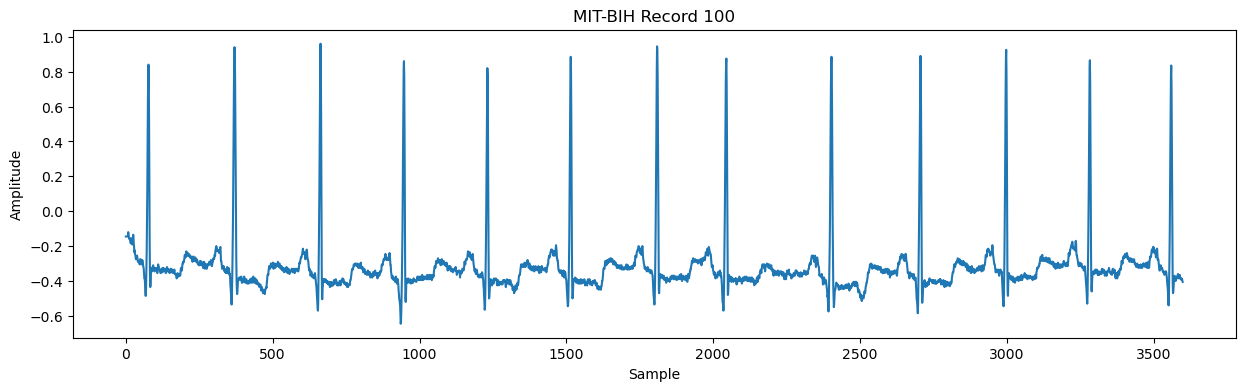

In [59]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 4))

plt.plot(record.p_signal[:3600, 0])

plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("MIT-BIH Record 100")
plt.show()

# UNDERSTANDING OF ANNOTATIONS

In [60]:
print(annotation.sample[:20])
print(annotation.symbol[:20])

[  18   77  370  662  946 1231 1515 1809 2044 2402 2706 2998 3282 3560
 3862 4170 4466 4764 5060 5346]
['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']


# CONVERT SYMBOL INTO ML CLASSES

In [61]:
beat_mapping = {
    # Normal
    "N": "N",
    "L": "N",
    "R": "N",
    "e": "N",
    "j": "N",

    # Supraventricular
    "A": "S",
    "a": "S",
    "J": "S",
    "S": "S",

    # Ventricular
    "V": "V",
    "E": "V",

    # Fusion
    "F": "F",

    # Unknown
    "/": "Q",
    "f": "Q",
    "Q": "Q"
}

# EXTRACT INDIVIDUAL HEARTBEATS

In [62]:
def extract_beats(record_name, channel=0):

    record = wfdb.rdrecord(record_name, pn_dir="mitdb")
    annotation = wfdb.rdann(record_name, "atr", pn_dir="mitdb")

    signal = record.p_signal[:, channel]
    fs = record.fs

    before = 180
    after = 180

    data = []

    for i, (sample, symbol) in enumerate(
        zip(annotation.sample, annotation.symbol)
    ):

        # Ignore symbols that aren't in our mapping
        if symbol not in beat_mapping:
            continue

        # Avoid beats too close to beginning/end
        if sample - before < 0:
            continue

        if sample + after >= len(signal):
            continue

        # Extract ECG beat
        beat = signal[
            sample - before:
            sample + after
        ]

        # Previous RR interval
        if i > 0:
            prev_rr = (
                sample - annotation.sample[i - 1]
            ) / fs
        else:
            prev_rr = np.nan

        # Next RR interval
        if i < len(annotation.sample) - 1:
            next_rr = (
                annotation.sample[i + 1] - sample
            ) / fs
        else:
            next_rr = np.nan

        data.append({
            "record": record_name,
            "sample": sample,
            "symbol": symbol,
            "label": beat_mapping[symbol],
            "beat": beat,
            "prev_rr": prev_rr,
            "next_rr": next_rr
        })

    return data

# TEST ON RECORD 100

In [63]:
beats_100 = extract_beats("100")

print("Number of beats:", len(beats_100))

Number of beats: 2271


In [64]:
print(beats_100[0])

{'record': '100', 'sample': np.int64(370), 'symbol': 'N', 'label': 'N', 'beat': array([-0.335, -0.34 , -0.315, -0.3  , -0.3  , -0.29 , -0.295, -0.29 ,
       -0.285, -0.275, -0.255, -0.25 , -0.25 , -0.265, -0.255, -0.245,
       -0.23 , -0.245, -0.245, -0.255, -0.255, -0.24 , -0.25 , -0.255,
       -0.245, -0.255, -0.25 , -0.25 , -0.265, -0.26 , -0.26 , -0.265,
       -0.27 , -0.265, -0.26 , -0.275, -0.28 , -0.29 , -0.275, -0.27 ,
       -0.26 , -0.28 , -0.28 , -0.285, -0.275, -0.275, -0.265, -0.27 ,
       -0.285, -0.29 , -0.28 , -0.275, -0.285, -0.28 , -0.3  , -0.3  ,
       -0.305, -0.295, -0.3  , -0.31 , -0.31 , -0.305, -0.295, -0.285,
       -0.285, -0.29 , -0.295, -0.31 , -0.29 , -0.295, -0.3  , -0.305,
       -0.31 , -0.325, -0.31 , -0.3  , -0.29 , -0.31 , -0.325, -0.33 ,
       -0.315, -0.3  , -0.305, -0.31 , -0.32 , -0.33 , -0.325, -0.315,
       -0.31 , -0.305, -0.305, -0.31 , -0.3  , -0.305, -0.29 , -0.3  ,
       -0.3  , -0.305, -0.305, -0.29 , -0.28 , -0.295, -0.305, -0.31

# ONE EXTRACTED HEARTBEAT

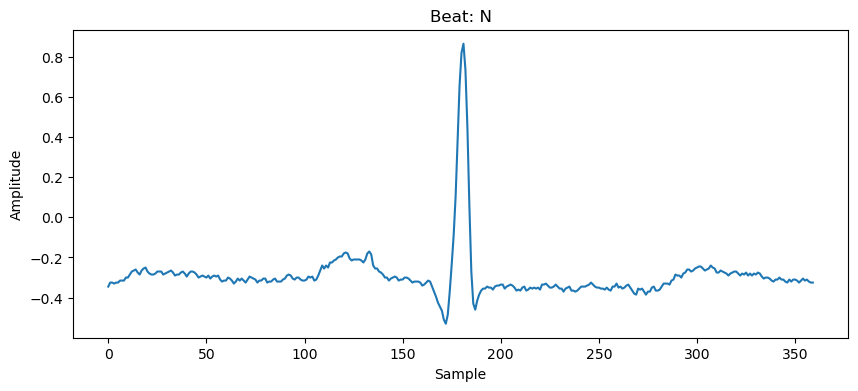

In [65]:
plt.figure(figsize=(10, 4))

plt.plot(beats_100[10]["beat"])

plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title(
    f"Beat: {beats_100[10]['label']}"
)

plt.show()

# HEARTBEAT INTO ML FEATURES

In [66]:
from scipy.stats import skew, kurtosis
def extract_features(item):

    beat = item["beat"]

    # Normalize beat
    beat_norm = (
        beat - np.mean(beat)
    ) / (np.std(beat) + 1e-8)

    features = {
        "mean": np.mean(beat),
        "std": np.std(beat),
        "min": np.min(beat),
        "max": np.max(beat),
        "range": np.ptp(beat),

        "rms": np.sqrt(
            np.mean(beat ** 2)
        ),

        "energy": np.sum(
            beat ** 2
        ),

        "skewness": skew(beat),
        "kurtosis": kurtosis(beat),

        "prev_rr": item["prev_rr"],
        "next_rr": item["next_rr"],

        "label": item["label"],
        "record": item["record"],
        "sample": item["sample"]
    }

    # Downsample ECG morphology to 60 points
    downsampled = np.interp(
        np.linspace(
            0,
            len(beat_norm) - 1,
            60
        ),
        np.arange(len(beat_norm)),
        beat_norm
    )

    for i, value in enumerate(downsampled):
        features[f"ecg_{i}"] = value

    return features

# CREATE DATAFRAME

In [67]:
feature_data = [
    extract_features(item)
    for item in beats_100
]

df = pd.DataFrame(feature_data)

In [68]:
df.head()

,mean,std,min,max,range,rms,energy,skewness,kurtosis,prev_rr,...,ecg_50,ecg_51,ecg_52,ecg_53,ecg_54,ecg_55,ecg_56,ecg_57,ecg_58,ecg_59
0,-0.309792,0.169131,-0.535,0.940,1.475,0.352954,44.847425,5.099975,30.913988,0.813889,...,0.057894,0.047372,0.057894,-0.001733,0.065911,-0.030795,-0.074888,-0.094931,-0.119483,-0.149046
1,-0.332389,0.153550,-0.570,0.960,1.530,0.366142,48.261600,5.974568,41.714788,0.811111,...,0.138082,0.079579,0.165125,0.080683,-0.030803,-0.114693,-0.122972,-0.131250,-0.185337,-0.212381
2,-0.332958,0.145797,-0.645,0.860,1.505,0.363481,47.562525,5.654252,39.148715,0.788889,...,0.286506,0.353351,0.287088,0.158049,0.078416,0.077835,0.037728,-0.070967,0.017384,-0.048298
3,-0.331958,0.138210,-0.565,0.820,1.385,0.359581,46.547375,5.651994,39.482946,0.791667,...,0.139869,0.147227,0.354477,0.212836,0.092042,0.050346,-0.040403,0.014169,0.080391,-0.058185
4,-0.325750,0.146924,-0.545,0.885,1.430,0.357351,45.971900,5.526280,37.605972,0.788889,...,0.279085,0.345417,0.379448,0.295235,0.257743,0.152765,0.081819,0.067399,0.107198,0.005105


In [69]:
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2271 entries, 0 to 2270
Data columns (total 74 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   mean      2271 non-null   float64
 1   std       2271 non-null   float64
 2   min       2271 non-null   float64
 3   max       2271 non-null   float64
 4   range     2271 non-null   float64
 5   rms       2271 non-null   float64
 6   energy    2271 non-null   float64
 7   skewness  2271 non-null   float64
 8   kurtosis  2271 non-null   float64
 9   prev_rr   2271 non-null   float64
 10  next_rr   2271 non-null   float64
 11  label     2271 non-null   object 
 12  record    2271 non-null   object 
 13  sample    2271 non-null   int64  
 14  ecg_0     2271 non-null   float64
 15  ecg_1     2271 non-null   float64
 16  ecg_2     2271 non-null   float64
 17  ecg_3     2271 non-null   float64
 18  ecg_4     2271 non-null   float64
 19  ecg_5     2271 non-null   float64
 20  ecg_6     2271 non-null   floa

,mean,std,min,max,range,rms,energy,skewness,kurtosis,prev_rr,...,ecg_50,ecg_51,ecg_52,ecg_53,ecg_54,ecg_55,ecg_56,ecg_57,ecg_58,ecg_59
count,2271.000000,2271.000000,2271.000000,2271.000000,2271.000000,2271.000000,2271.000000,2271.000000,2271.000000,2271.000000,...,2271.000000,2271.000000,2271.000000,2271.000000,2271.000000,2271.000000,2271.000000,2271.000000,2271.000000,2271.000000
mean,-0.305500,0.166127,-0.560513,0.986576,1.547089,0.349265,44.575656,5.320723,34.484157,0.794629,...,0.182651,0.191161,0.171548,0.138578,0.095344,0.048003,-0.004925,-0.047113,-0.075558,-0.082788
std,0.049694,0.020609,0.070503,0.130789,0.121127,0.042849,11.127534,0.440731,4.147155,0.048828,...,0.164377,0.166082,0.169083,0.180219,0.188402,0.196677,0.202695,0.205611,0.210527,0.227017
min,-0.512069,0.124568,-2.715000,0.605000,1.095000,0.154015,8.539425,-1.267697,4.741689,0.522222,...,-0.446537,-0.448764,-0.468990,-0.510121,-0.589463,-0.609733,-0.685592,-0.740501,-0.751232,-1.000929
25%,-0.337639,0.151908,-0.595000,0.885000,1.460000,0.320578,36.997250,5.056923,31.768673,0.772222,...,0.077663,0.088504,0.062099,0.021380,-0.024693,-0.079471,-0.138922,-0.184293,-0.218686,-0.229686
50%,-0.302931,0.164138,-0.560000,0.970000,1.540000,0.345766,43.039450,5.370816,34.900904,0.797222,...,0.180675,0.187763,0.167971,0.137005,0.091575,0.041786,-0.008613,-0.054683,-0.082896,-0.101196
75%,-0.272778,0.175922,-0.525000,1.080000,1.625000,0.376748,51.098188,5.629758,37.614584,0.822222,...,0.284228,0.296868,0.274521,0.252962,0.210403,0.168153,0.118858,0.082406,0.059552,0.050621
max,0.017375,0.614860,-0.270000,1.435000,3.675000,0.659381,156.522025,6.464480,44.908102,1.130556,...,1.110342,1.232997,1.095245,1.361290,1.171893,1.096738,0.969285,1.200301,0.879237,1.411486


In [70]:
df = df.dropna()
print(df.shape)

(2271, 74)


In [71]:
print(df["label"].value_counts())

label
N    2237
S      33
V       1
Name: count, dtype: int64


In [72]:
records = wfdb.get_record_list("mitdb")
print(records)
print("Number of records:", len(records))

['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']
Number of records: 48


# COMPLETE DATASET

In [73]:
all_features = []


for record_name in records:

    print("record:", record_name)

    try:
        beats = extract_beats(record_name)

        for beat in beats:
            features = extract_features(beat)
            all_features.append(features)

    except Exception as e:
        print("Error in",record_name,":",e)

record: 100
record: 101
record: 102
record: 103
record: 104
record: 105
record: 106
record: 107
record: 108
record: 109
record: 111
record: 112
record: 113
record: 114
record: 115
record: 116
record: 117
record: 118
record: 119
record: 121
record: 122
record: 123
record: 124
record: 200
record: 201
record: 202
record: 203
record: 205
record: 207
record: 208
record: 209
record: 210
record: 212
record: 213
record: 214
record: 215
record: 217
record: 219
record: 220
record: 221
record: 222
record: 223
record: 228
record: 230
record: 231
record: 232
record: 233
record: 234


In [74]:
df = pd.DataFrame(all_features)

In [75]:
print(df.shape)

(109438, 74)


In [78]:
df.head()

,mean,std,min,max,range,rms,energy,skewness,kurtosis,prev_rr,...,ecg_50,ecg_51,ecg_52,ecg_53,ecg_54,ecg_55,ecg_56,ecg_57,ecg_58,ecg_59
0,-0.309792,0.169131,-0.535,0.940,1.475,0.352954,44.847425,5.099975,30.913988,0.813889,...,0.057894,0.047372,0.057894,-0.001733,0.065911,-0.030795,-0.074888,-0.094931,-0.119483,-0.149046
1,-0.332389,0.153550,-0.570,0.960,1.530,0.366142,48.261600,5.974568,41.714788,0.811111,...,0.138082,0.079579,0.165125,0.080683,-0.030803,-0.114693,-0.122972,-0.131250,-0.185337,-0.212381
2,-0.332958,0.145797,-0.645,0.860,1.505,0.363481,47.562525,5.654252,39.148715,0.788889,...,0.286506,0.353351,0.287088,0.158049,0.078416,0.077835,0.037728,-0.070967,0.017384,-0.048298
3,-0.331958,0.138210,-0.565,0.820,1.385,0.359581,46.547375,5.651994,39.482946,0.791667,...,0.139869,0.147227,0.354477,0.212836,0.092042,0.050346,-0.040403,0.014169,0.080391,-0.058185
4,-0.325750,0.146924,-0.545,0.885,1.430,0.357351,45.971900,5.526280,37.605972,0.788889,...,0.279085,0.345417,0.379448,0.295235,0.257743,0.152765,0.081819,0.067399,0.107198,0.005105


In [115]:
df.to_csv(
    "MIT_BIH_ECG_ML_Dataset.csv1",
    index=False
)

In [4]:
df = pd.read_csv("MIT_BIH_ECG_ML_Dataset.csv1")

In [5]:
df.head()

,mean,std,min,max,range,rms,energy,skewness,kurtosis,prev_rr,...,ecg_50,ecg_51,ecg_52,ecg_53,ecg_54,ecg_55,ecg_56,ecg_57,ecg_58,ecg_59
0,-0.309792,0.169131,-0.535,0.940,1.475,0.352954,44.847425,5.099975,30.913988,0.813889,...,0.057894,0.047372,0.057894,-0.001733,0.065911,-0.030795,-0.074888,-0.094931,-0.119483,-0.149046
1,-0.332389,0.153550,-0.570,0.960,1.530,0.366142,48.261600,5.974568,41.714788,0.811111,...,0.138082,0.079579,0.165125,0.080683,-0.030803,-0.114693,-0.122972,-0.131250,-0.185337,-0.212381
2,-0.332958,0.145797,-0.645,0.860,1.505,0.363481,47.562525,5.654252,39.148715,0.788889,...,0.286506,0.353351,0.287088,0.158049,0.078416,0.077835,0.037728,-0.070967,0.017384,-0.048298
3,-0.331958,0.138210,-0.565,0.820,1.385,0.359581,46.547375,5.651994,39.482946,0.791667,...,0.139869,0.147227,0.354477,0.212836,0.092042,0.050346,-0.040403,0.014169,0.080391,-0.058185
4,-0.325750,0.146924,-0.545,0.885,1.430,0.357351,45.971900,5.526280,37.605972,0.788889,...,0.279085,0.345417,0.379448,0.295235,0.257743,0.152765,0.081819,0.067399,0.107198,0.005105


In [6]:
df["record"]

0         100
1         100
2         100
3         100
4         100
         ... 
109433    234
109434    234
109435    234
109436    234
109437    234
Name: record, Length: 109438, dtype: int64

In [9]:
df.isnull().sum()

mean      0
std       0
min       0
max       0
range     0
         ..
ecg_55    0
ecg_56    0
ecg_57    0
ecg_58    0
ecg_59    0
Length: 74, dtype: int64

In [7]:
df["label"].unique()

array(['N', 'S', 'V', 'Q', 'F'], dtype=object)

In [8]:
categorical_cols=df.select_dtypes(include=['object']).columns
numerical_cols=df.select_dtypes(include=['number']).columns

In [9]:
from sklearn.impute import SimpleImputer
num_imp= SimpleImputer(strategy="mean")
df[numerical_cols]=num_imp.fit_transform(df[numerical_cols])

cat_imp= SimpleImputer(strategy="most_frequent")
df[categorical_cols]=cat_imp.fit_transform(df[categorical_cols])

In [10]:
df.columns

Index(['mean', 'std', 'min', 'max', 'range', 'rms', 'energy', 'skewness',
       'kurtosis', 'prev_rr', 'next_rr', 'label', 'record', 'sample', 'ecg_0',
       'ecg_1', 'ecg_2', 'ecg_3', 'ecg_4', 'ecg_5', 'ecg_6', 'ecg_7', 'ecg_8',
       'ecg_9', 'ecg_10', 'ecg_11', 'ecg_12', 'ecg_13', 'ecg_14', 'ecg_15',
       'ecg_16', 'ecg_17', 'ecg_18', 'ecg_19', 'ecg_20', 'ecg_21', 'ecg_22',
       'ecg_23', 'ecg_24', 'ecg_25', 'ecg_26', 'ecg_27', 'ecg_28', 'ecg_29',
       'ecg_30', 'ecg_31', 'ecg_32', 'ecg_33', 'ecg_34', 'ecg_35', 'ecg_36',
       'ecg_37', 'ecg_38', 'ecg_39', 'ecg_40', 'ecg_41', 'ecg_42', 'ecg_43',
       'ecg_44', 'ecg_45', 'ecg_46', 'ecg_47', 'ecg_48', 'ecg_49', 'ecg_50',
       'ecg_51', 'ecg_52', 'ecg_53', 'ecg_54', 'ecg_55', 'ecg_56', 'ecg_57',
       'ecg_58', 'ecg_59'],
      dtype='object')

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [12]:
df.isnull().sum()

mean      0
std       0
min       0
max       0
range     0
         ..
ecg_55    0
ecg_56    0
ecg_57    0
ecg_58    0
ecg_59    0
Length: 74, dtype: int64

In [13]:
X = df.drop(columns=["label", "record", "sample", 'prev_rr', 'next_rr'])
y = df["label"]

In [14]:
y.unique()

array(['N', 'S', 'V', 'Q', 'F'], dtype=object)

In [15]:
from sklearn.model_selection import GroupShuffleSplit

groups = df["record"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]


In [16]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

# MAKE MODEL

In [17]:
model = RandomForestClassifier(
    n_estimators=501,
    class_weight="balanced",
    max_depth = None,
    oob_score = True,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_scaled,y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=501, n_jobs=-1,
                       oob_score=True, random_state=42)

In [18]:
y_pred = model.predict(X_test_scaled)

In [19]:
print("accuracy: ", accuracy_score(y_test, y_pred))
print("precision: ", precision_score(y_test, y_pred, average="weighted",zero_division=0))
print("recall: ", recall_score(y_test, y_pred, average="weighted",zero_division=0))
print("f1_score: ", f1_score(y_test, y_pred, average="weighted",zero_division=0))

accuracy:  0.9075193316149676
precision:  0.8938320259263569
recall:  0.9075193316149676
f1_score:  0.8904284515555164


In [20]:
print("accuracy: ", accuracy_score(y_test, y_pred))
print("precision: ", precision_score(y_test, y_pred, average="macro",zero_division=0))
print("recall: ", recall_score(y_test, y_pred, average="macro",zero_division=0))
print("f1_score: ", f1_score(y_test, y_pred, average="macro",zero_division=0))

accuracy:  0.9075193316149676
precision:  0.5433254699635117
recall:  0.42228293233845837
f1_score:  0.4606063506789283


In [21]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

              precision    recall  f1-score   support

           F       0.12      0.06      0.08        16
           N       0.91      0.99      0.95     19209
           Q       1.00      0.47      0.64      2066
           S       0.00      0.00      0.00       411
           V       0.68      0.59      0.64       800

    accuracy                           0.91     22502
   macro avg       0.54      0.42      0.46     22502
weighted avg       0.89      0.91      0.89     22502



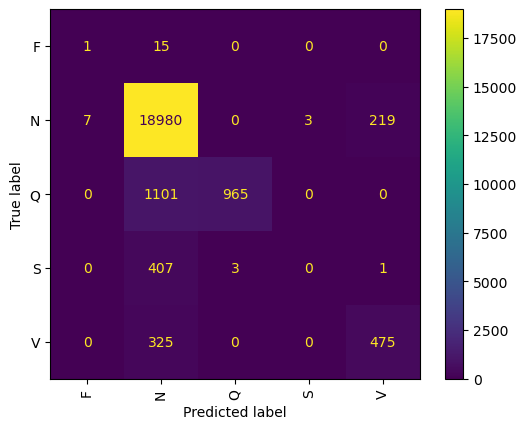

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation="vertical"
)

plt.show()

In [26]:
y_train.value_counts()

label
N    71373
V     6435
Q     5972
S     2370
F      786
Name: count, dtype: int64

In [22]:
from sklearn.model_selection import StratifiedGroupKFold

sgkf = StratifiedGroupKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

train_idx, test_idx = next(
    sgkf.split(X, y, groups=df["record"])
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

In [23]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [24]:
model_1 = RandomForestClassifier(
    n_estimators=501,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model_1.fit(X_train_scaled, y_train)


RandomForestClassifier(class_weight='balanced', n_estimators=501, n_jobs=-1,
                       random_state=42)

In [30]:
y_pred = model_1.predict(X_test_scaled)

In [31]:
print("accuracy: ", accuracy_score(y_test, y_pred))
print("precision: ", precision_score(y_test, y_pred, average="weighted",zero_division=0))
print("recall: ", recall_score(y_test, y_pred, average="weighted",zero_division=0))
print("f1_score: ", f1_score(y_test, y_pred, average="weighted",zero_division=0))

accuracy:  0.8619020501138952
precision:  0.8821346076310189
recall:  0.8619020501138952
f1_score:  0.8363383480835791


In [32]:
print("accuracy: ", accuracy_score(y_test, y_pred))
print("precision: ", precision_score(y_test, y_pred, average="macro",zero_division=0))
print("recall: ", recall_score(y_test, y_pred, average="macro",zero_division=0))
print("f1_score: ", f1_score(y_test, y_pred, average="macro",zero_division=0))

accuracy:  0.8619020501138952
precision:  0.5698527887207133
recall:  0.3612302266114099
f1_score:  0.4132669688480946


In [33]:
print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

              precision    recall  f1-score   support

           F       0.00      0.00      0.00         1
           N       0.85      1.00      0.92      8192
           Q       1.00      0.37      0.54      2062
           S       0.00      0.00      0.00         6
           V       1.00      0.43      0.60       275

    accuracy                           0.86     10536
   macro avg       0.57      0.36      0.41     10536
weighted avg       0.88      0.86      0.84     10536

